In [ ]:
!pip install fastf1 torch numpy matplotlib

In [ ]:
import fastf1
import numpy as np
import os

# ✅ CREATE CACHE DIRECTORY
os.makedirs('/content/cache', exist_ok=True)

# ✅ ENABLE CACHE
fastf1.Cache.enable_cache('/content/cache')

# Load session
session = fastf1.get_session(2023, 'Monza', 'Q')
session.load()

lap = session.laps.pick_fastest()
telemetry = lap.get_telemetry()

track = np.vstack((telemetry['X'], telemetry['Y'])).T

# Normalize
track = track - track.mean(axis=0)
track = track / np.max(np.linalg.norm(track, axis=1))

# Close loop
track = np.vstack((track, track[0]))

core           INFO 	Loading data for Italian Grand Prix - Qualifying [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for Italian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req         

In [ ]:
# class F1Env:
#     def __init__(self, track):
#         self.track = track
#         self.n = len(track)

#         self.track_width = 0.12   # slightly wider → easier learning
#         self.max_steps = 1000     # shorter episodes = faster training

#     def reset(self):
#         self.pos = self.track[0].copy()
#         self.vel = np.zeros(2)

#         self.progress = 0
#         self.steps = 0

#         return self._obs()

#     def _obs(self):
#         target = self.track[self.progress]
#         return np.concatenate([self.pos, self.vel, target]).astype(np.float32)

#     def step(self, action):
#         steering, throttle = action

#         # ---- Direction toward next point ----
#         target = self.track[self.progress]
#         direction = target - self.pos
#         direction /= (np.linalg.norm(direction) + 1e-6)

#         # ---- Physics (simple but stable) ----
#         self.vel += throttle * direction * 0.04
#         self.vel *= 0.97
#         self.pos += self.vel

#         dist = np.linalg.norm(self.pos - target)

#         reward = 0

#         # ✅ STRONG progress reward (main learning signal)
#         if dist < self.track_width:
#             self.progress += 1
#             reward += 120

#         # ✅ SAFE distance penalty (prevents explosion)
#         reward -= min(dist, 1.0) * 2

#         # ✅ small speed incentive
#         reward += np.linalg.norm(self.vel) * 0.5

#         # ❌ off-track penalty (not too harsh)
#         if dist > self.track_width * 3:
#             reward -= 20

#         # ---- Step update ----
#         self.steps += 1

#         done = False

#         # 🏁 Full lap completion
#         if self.progress >= self.n - 1:
#             done = True
#             reward += 15000

#         # ⛔ Early kill for bad episodes (VERY IMPORTANT)
#         if self.progress < 5 and self.steps > 150:
#             return self._obs(), -100, True

#         # ⛔ Max steps
#         if self.steps >= self.max_steps:
#             done = True

#         return self._obs(), reward, done

In [ ]:
# class F1Env:
#     def __init__(self, track):
#         self.track = track
#         self.n = len(track)

#         self.track_width = 0.12
#         self.max_steps = 1000

#     def reset(self):
#         self.pos = self.track[0].copy()
#         self.vel = np.zeros(2)

#         self.progress = 0
#         self.steps = 0

#         self.prev_vel = np.zeros(2)

#         return self._obs()

#     def _obs(self):
#         target = self.track[self.progress]
#         return np.concatenate([self.pos, self.vel, target]).astype(np.float32)

#     def step(self, action):
#         steering, throttle = action

#         # ✅ LOOKAHEAD (keep this — important)
#         next_idx = min(self.progress + 5, self.n - 1)
#         target = self.track[next_idx]

#         direction = target - self.pos
#         direction /= (np.linalg.norm(direction) + 1e-6)

#         # ✅ SIMPLE MOVEMENT (no heading yet)
#         self.vel += throttle * direction * 0.05
#         self.vel *= 0.97
#         self.pos += self.vel

#         dist = np.linalg.norm(self.pos - self.track[self.progress])

#         reward = 0

#         # ✅ Progress
#         if dist < self.track_width:
#             self.progress += 1
#             reward += 120

#         # ✅ Distance penalty
#         reward -= min(dist, 1.0) * 2

#         # ✅ Speed reward
#         reward += np.linalg.norm(self.vel) * 0.5

#         # 🧠 LIGHT smoothness (NOT too strong)
#         reward -= np.linalg.norm(self.vel - self.prev_vel) * 1.0

#         # ❌ Off track
#         if dist > self.track_width * 3:
#             reward -= 20

#         self.prev_vel = self.vel.copy()

#         self.steps += 1

#         done = False

#         if self.progress >= self.n - 5:
#             done = True
#             reward += 15000

#         if self.progress < 5 and self.steps > 150:
#             return self._obs(), -100, True

#         if self.steps >= self.max_steps:
#             done = True

#         return self._obs(), reward, done

In [ ]:
class F1Env:
    def __init__(self, track):
        self.track = track
        self.n = len(track)

        self.track_width = 0.12
        self.max_steps = 1000

    def reset(self):
        self.pos = self.track[0].copy()
        self.vel = np.zeros(2)

        self.progress = 0
        self.steps = 0

        self.prev_vel = np.zeros(2)

        return self._obs()

    def _obs(self):
        target = self.track[self.progress]
        return np.concatenate([self.pos, self.vel, target]).astype(np.float32)

    def step(self, action):
        steering, throttle = action

        # ✅ LOOKAHEAD (bigger = smoother turns)
        next_idx = min(self.progress + 10, self.n - 1)
        target = self.track[next_idx]

        direction = target - self.pos
        direction /= (np.linalg.norm(direction) + 1e-6)

        # ✅ MOVEMENT
        self.vel += throttle * direction * 0.05

        # ✅ DAMPING (reduces oscillations)
        self.vel *= 0.92

        # ✅ SPEED LIMIT (prevents crazy jumps)
        max_speed = 0.05
        speed = np.linalg.norm(self.vel)
        if speed > max_speed:
            self.vel = self.vel / speed * max_speed

        self.pos += self.vel

        dist = np.linalg.norm(self.pos - self.track[self.progress])

        reward = 0

        # ✅ PROGRESS REWARD
        if dist < self.track_width:
            self.progress += 1
            reward += 120

        # ✅ DISTANCE PENALTY
        reward -= min(dist, 1.0) * 2

        # ✅ SPEED REWARD
        reward += np.linalg.norm(self.vel) * 0.5

        # 🔥 STRONG SMOOTHNESS (KEY FIX)
        reward -= np.linalg.norm(self.vel - self.prev_vel) * 4.0

        # ❌ OFF TRACK
        if dist > self.track_width * 3:
            reward -= 20

        self.prev_vel = self.vel.copy()

        self.steps += 1

        done = False

        # 🏁 FULL LAP
        if self.progress >= self.n - 5:
            done = True
            reward += 15000

        # ⛔ EARLY KILL
        if self.progress < 5 and self.steps > 150:
            return self._obs(), -100, True

        if self.steps >= self.max_steps:
            done = True

        return self._obs(), reward, done

In [ ]:
import torch
import torch.nn as nn

class Policy(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
import torch
import numpy as np

env = F1Env(track)
policy = Policy()

optimizer = torch.optim.Adam(policy.parameters(), lr=1e-3)

gamma = 0.99

# for episode in range(300):

#     obs = env.reset()
#     log_probs = []
#     rewards = []

#     done = False

#     while not done:
#         obs_tensor = torch.tensor(obs, dtype=torch.float32)

#         # Forward pass
#         action = policy(obs_tensor)

#         # Convert to numpy
#         action_np = action.detach().numpy()

#         # ✅ BETTER EXPLORATION
#         action_np += np.random.normal(0, 0.2, size=2)

#         # Clip action
#         action_np = np.clip(action_np, -1, 1)

#         next_obs, reward, done = env.step(action_np)

#         # ✅ FIX LOG PROB (STABLE VERSION)
#         log_prob = -((action - torch.tensor(action_np, dtype=torch.float32))**2).mean()

#         log_probs.append(log_prob)
#         rewards.append(reward)

#         obs = next_obs

#     # ✅ COMPUTE RETURNS (STABLE)
#     returns = []
#     G = 0
#     for r in reversed(rewards):
#         G = r + gamma * G
#         returns.insert(0, G)

#     returns = torch.tensor(returns, dtype=torch.float32)

#     # Normalize
#     returns = (returns - returns.mean()) / (returns.std() + 1e-8)

#     # ✅ LOSS
#     loss = 0
#     for log_prob, G in zip(log_probs, returns):
#         loss += -log_prob * G

#     # Backprop
#     optimizer.zero_grad()
#     loss.backward()

#     # ✅ GRADIENT CLIPPING (IMPORTANT)
#     torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)

#     optimizer.step()

#     # ✅ PRINT PROGRESS (CRITICAL)
#     if episode % 10 == 0:
#         print(f"Episode {episode}, Reward: {sum(rewards):.2f}, Progress: {env.progress}/{env.n}")
for episode in range(250):

    obs = env.reset()
    log_probs = []
    rewards = []

    done = False

    while not done:
        obs_tensor = torch.from_numpy(obs)

        action = policy(obs_tensor)
        action_np = action.detach().numpy()

        # exploration
        action_np += np.random.normal(0, 0.05, size=2)
        action_np = np.clip(action_np, -1, 1)

        next_obs, reward, done = env.step(action_np)

        log_prob = -((action - torch.tensor(action_np, dtype=torch.float32))**2).mean()

        log_probs.append(log_prob)
        rewards.append(reward)

        obs = next_obs

    # RETURNS
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + 0.99 * G
        returns.insert(0, G)

    returns = torch.tensor(returns, dtype=torch.float32)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    loss = 0
    for log_prob, G in zip(log_probs, returns):
        loss += -log_prob * G

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
    optimizer.step()

    if episode % 10 == 0:
        print(f"Episode {episode}, Reward: {sum(rewards):.2f}, Progress: {env.progress}/{env.n}")

Episode 0, Reward: 26184.50, Progress: 308/603
Episode 10, Reward: 86658.04, Progress: 598/603
Episode 20, Reward: 86660.63, Progress: 598/603
Episode 30, Reward: 28730.66, Progress: 319/603
Episode 40, Reward: 86629.39, Progress: 598/603
Episode 50, Reward: 39427.47, Progress: 377/603
Episode 60, Reward: 86673.89, Progress: 598/603
Episode 70, Reward: 86643.61, Progress: 598/603
Episode 80, Reward: 26130.10, Progress: 321/603
Episode 90, Reward: 86625.71, Progress: 598/603
Episode 100, Reward: 86643.07, Progress: 598/603
Episode 110, Reward: 22841.39, Progress: 301/603
Episode 120, Reward: 23075.08, Progress: 309/603
Episode 130, Reward: 20613.44, Progress: 287/603
Episode 140, Reward: 25117.25, Progress: 305/603
Episode 150, Reward: 29612.96, Progress: 337/603
Episode 160, Reward: 26051.21, Progress: 323/603
Episode 170, Reward: 25173.23, Progress: 316/603
Episode 180, Reward: 33382.66, Progress: 353/603
Episode 190, Reward: 86633.30, Progress: 598/603
Episode 200, Reward: 86559.84, 

Progress: 598 / 603


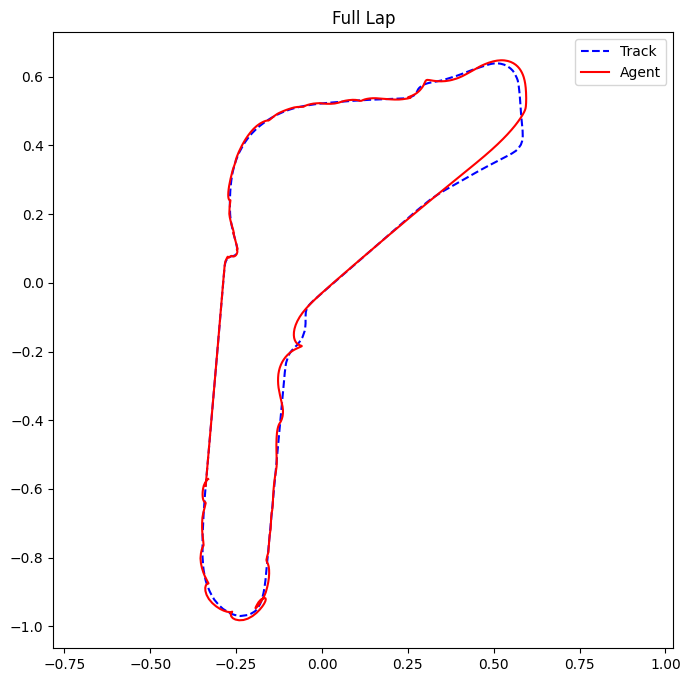

In [ ]:
import matplotlib.pyplot as plt

obs = env.reset()
positions = []

done = False

while not done:
    obs_tensor = torch.tensor(obs, dtype=torch.float32)
    action = policy(obs_tensor).detach().numpy()

    obs, reward, done = env.step(action)
    positions.append(env.pos.copy())

positions = np.array(positions)

print("Progress:", env.progress, "/", env.n)

plt.figure(figsize=(8,8))
plt.plot(track[:,0], track[:,1], 'b--', label="Track")
plt.plot(positions[:,0], positions[:,1], 'r', label="Agent")
plt.legend()
plt.axis('equal')
plt.title("Full Lap")
plt.show()

evaluation

In [ ]:
def compute_tracking_error(track, positions):
    errors = []

    for pos in positions:
        dists = np.linalg.norm(track - pos, axis=1)
        errors.append(np.min(dists))

    return np.mean(errors), np.max(errors)

In [ ]:
mean_err, max_err = compute_tracking_error(track, positions)

print(f"Mean Tracking Error: {mean_err:.4f}")
print(f"Max Tracking Error: {max_err:.4f}")

Mean Tracking Error: 0.0094
Max Tracking Error: 0.0512


In [ ]:
completion = env.progress / env.n

print(f"Lap Completion: {completion * 100:.2f}%")

Lap Completion: 99.17%


In [ ]:
def compute_smoothness(positions):
    velocities = np.diff(positions, axis=0)
    accel = np.diff(velocities, axis=0)

    return np.mean(np.linalg.norm(accel, axis=1))

In [ ]:
smoothness = compute_smoothness(positions)

print(f"Smoothness (lower is better): {smoothness:.4f}")

Smoothness (lower is better): 0.0009


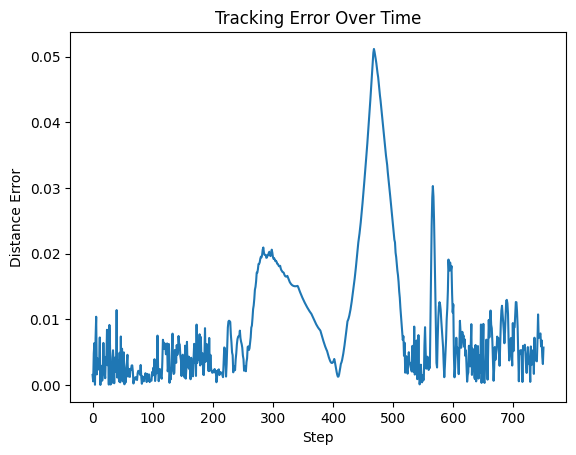

In [ ]:
errors = []

for pos in positions:
    dists = np.linalg.norm(track - pos, axis=1)
    errors.append(np.min(dists))

plt.plot(errors)
plt.title("Tracking Error Over Time")
plt.xlabel("Step")
plt.ylabel("Distance Error")
plt.show()